# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb
import numpy as np

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner
from astropy import constants as const
import astropy.units as u

from pytransit import TransitLPF

seterr('ignore')
seed(0)

C:\Users\stanl\anaconda3\envs\exoplanets\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

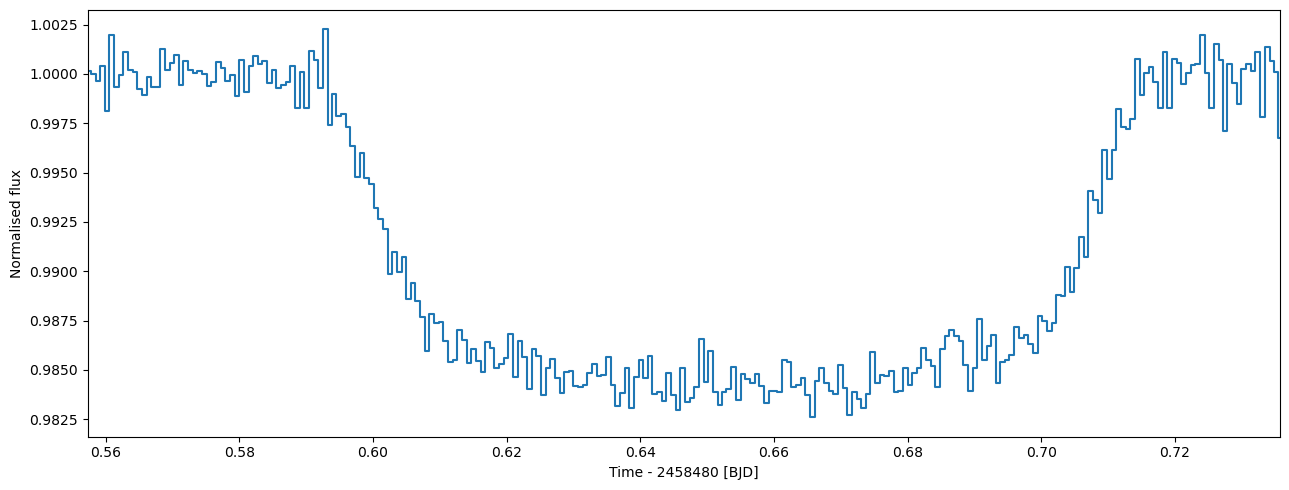

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

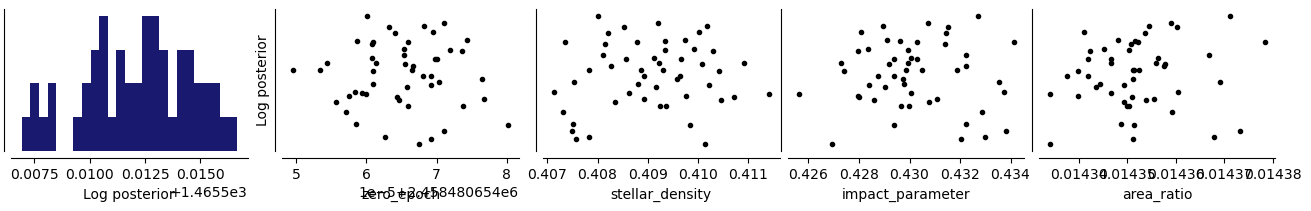

In [7]:
lpf.optimize_global(niter=500, npop=50)

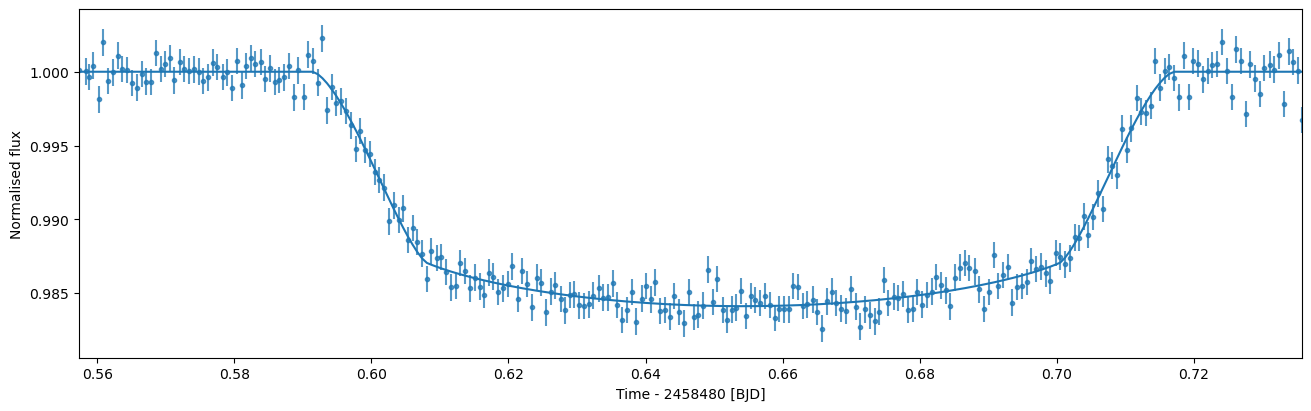

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling: 100%|█████████████████████████| 2/2 [00:16<00:00,  8.04s/it]


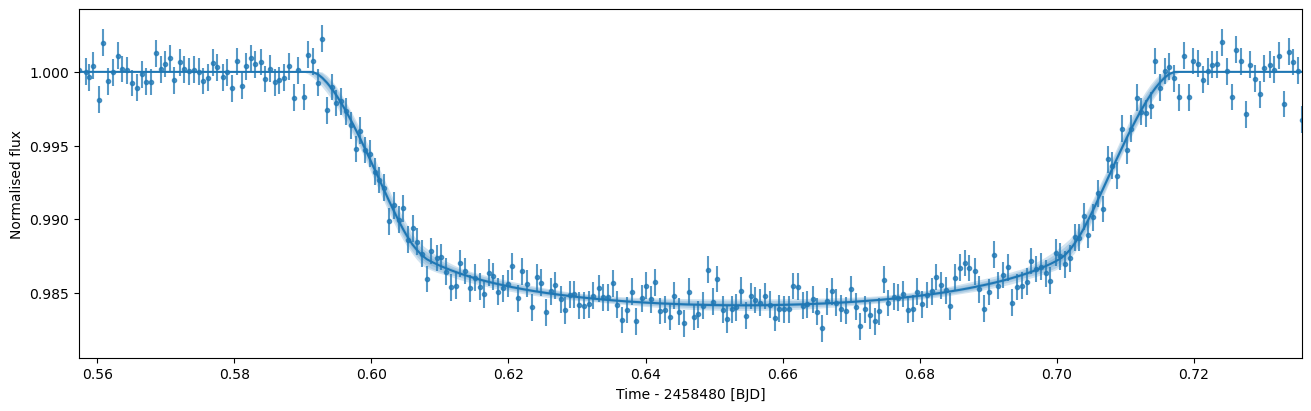

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

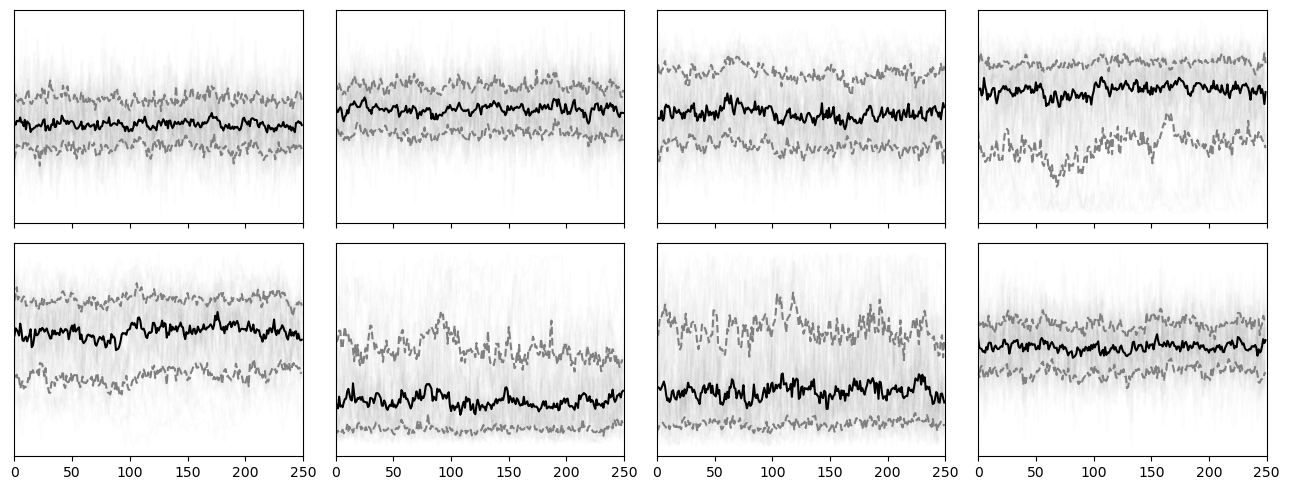

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

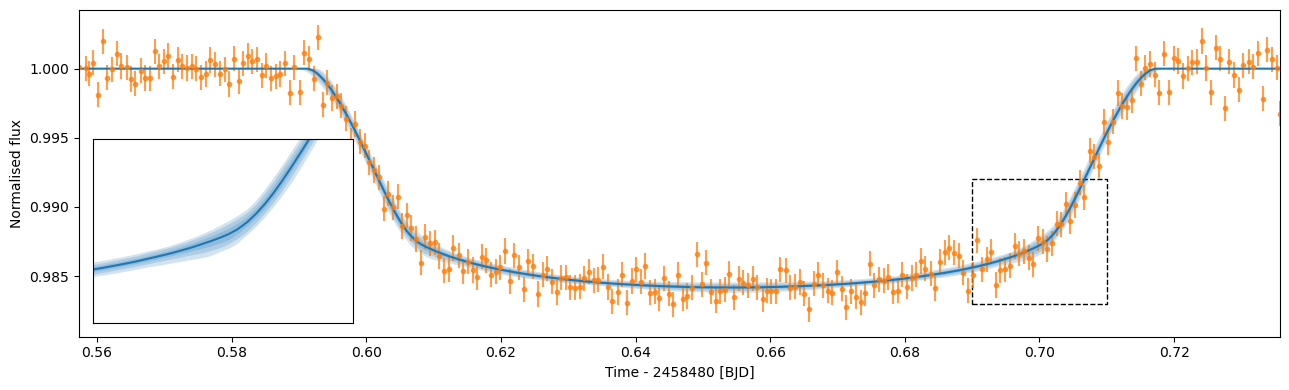

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4367,3.2871e-01,0.0139,0.3227,0.3463,-3.0407,0.1180,3.0161,1.4603,0.1258,0.0947
std,1.6164e-04,1.1074e-09,0.0367,1.2685e-01,0.0005,0.2038,0.2402,0.0192,0.0020,0.0847,0.0446,0.0010,0.0026
min,2.4585e+06,1.0914e+00,0.3284,4.8142e-05,0.0126,0.0467,0.0005,-3.1167,0.1120,2.7449,1.3620,0.1225,0.0872
25%,2.4585e+06,1.0914e+00,0.4090,2.5706e-01,0.0136,0.1612,0.1537,-3.0537,0.1166,2.9531,1.4268,0.1251,0.0927
50%,2.4585e+06,1.0914e+00,0.4338,3.6338e-01,0.0140,0.2678,0.2855,-3.0407,0.1183,3.0118,1.4499,0.1257,0.0945
75%,2.4585e+06,1.0914e+00,0.4658,4.2399e-01,0.0143,0.4355,0.5004,-3.0279,0.1196,3.0840,1.4874,0.1264,0.0968
max,2.4585e+06,1.0914e+00,0.5332,5.6988e-01,0.0150,0.9982,0.9997,-2.9684,0.1224,3.2260,1.5708,0.1299,0.1018


<Axes: >

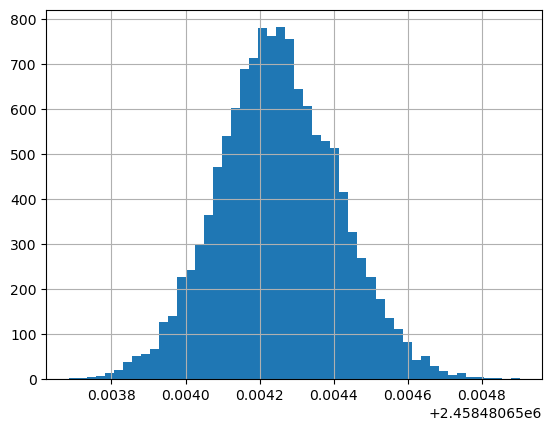

In [16]:
df.tc.hist(bins=50)

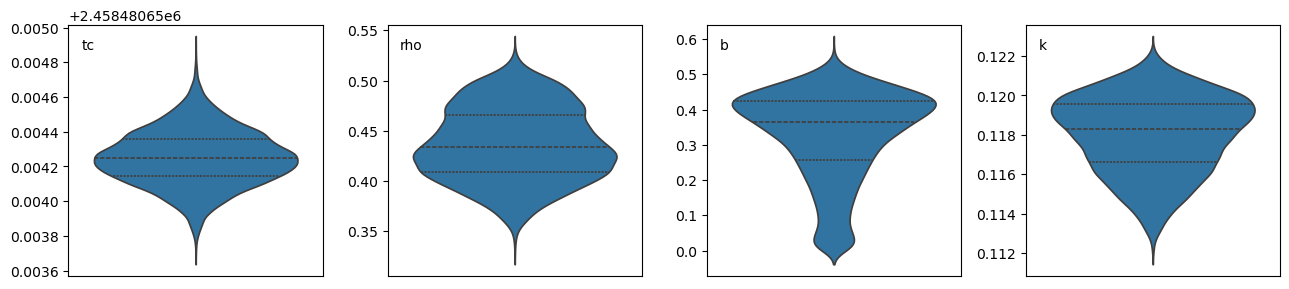

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

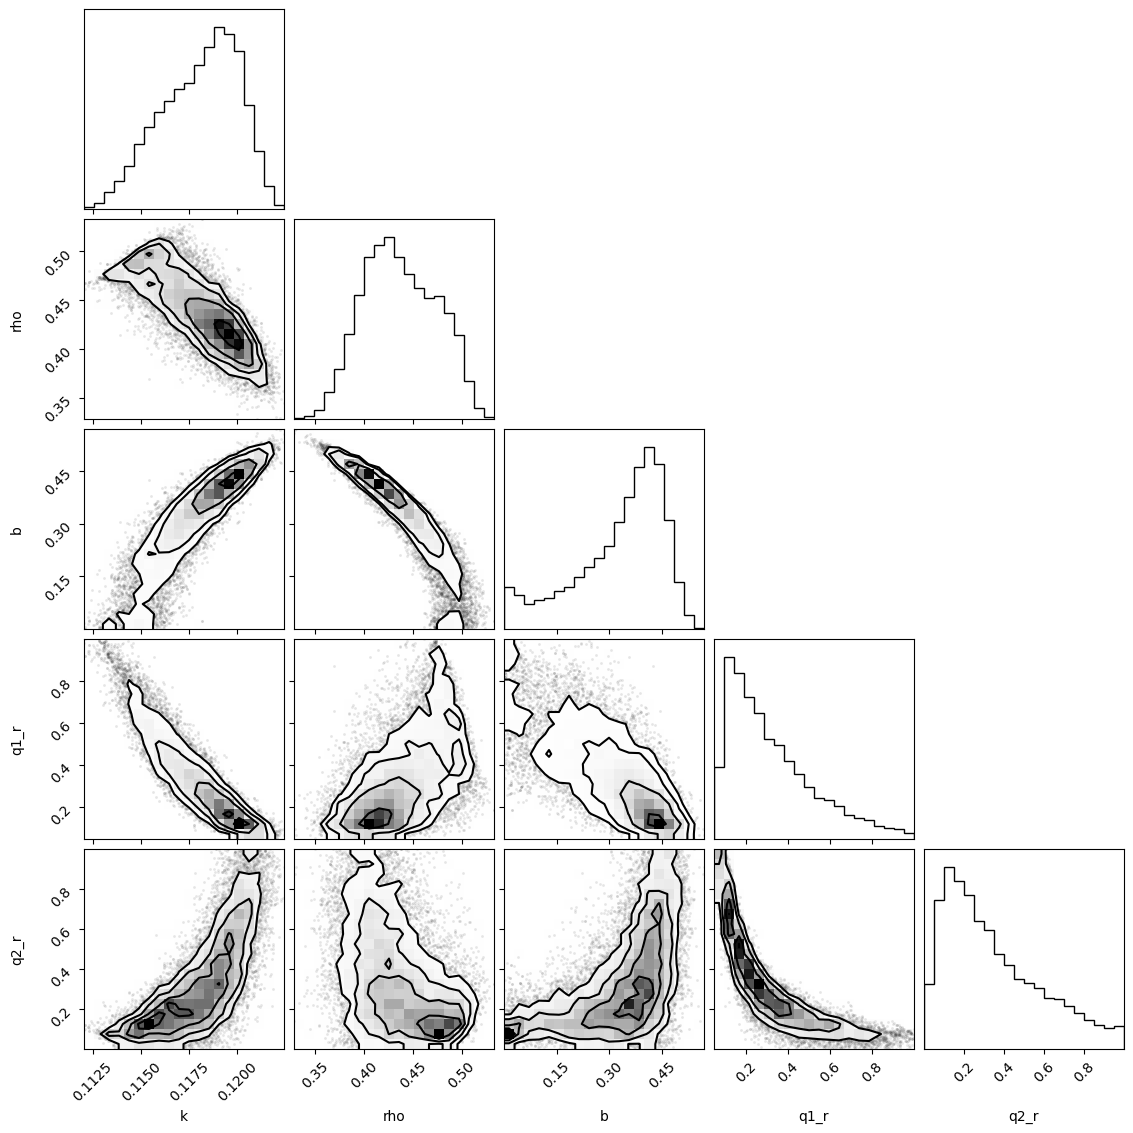

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

In [19]:
# Posterior samples of planet-star radius ratio
k = df.k.values

# Star radius
Rstar = 1.69 * const.R_sun

# Planet radius posterior cacl
Rp = k * Rstar

# Converting to Jupiter radii
Rp_rjup = Rp.to(u.R_jup)

r16, r50, r84 = np.percentile(Rp_rjup.value, [16, 50, 84])

print(f"Radius of Planet = {r50:.3f} +{r84-r50:.3f} -{r50-r16:.3f} R_Jup")

Radius of Planet = 1.946 +0.029 -0.040 R_Jup


2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

In [20]:
# Repeating mass estimate from Exercise 1
# m sin i = 1.391 +0.012 -0.013 M_Jup
# Since WASP-12b transits, sin(i) ~ 1, so Mp ~ m sin(i)

Mp_med = 1.391
Mp_err_plus = 0.012
Mp_err_minus = 0.013

# Approximate the asymmetric uncertainty with a Gaussian 
Mp_err = 0.5 * (Mp_err_plus + Mp_err_minus)

# Generate mass samples with same length as radius posterior
rng = np.random.default_rng(42)
Mp_samples = rng.normal(Mp_med, Mp_err, size=len(Rp_rjup)) * u.M_jup

# Bulk density calculation
rho_p = Mp_samples / ((4/3) * np.pi * Rp_rjup**3)
rho_p = rho_p.to(u.g / u.cm**3)

rho16, rho50, rho84 = np.percentile(rho_p.value, [16, 50, 84])

print(f"Planet Bulk Density = {rho50:.3f} +{rho84-rho50:.3f} -{rho50-rho16:.3f} g/cm^3")

Planet Bulk Density = 0.234 +0.015 -0.010 g/cm^3


3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

Once we have observed a transit, then through geometry we can say that the orbit of the planet is edge-on to our line-of-sight. This then means that our equation we used earlier for minimum planet mass (m sin i = 1.391), becomes a true mass estimate, as i is (or is very close to) 90deg. This makes sin i = 1, and therefore planet mass m = 1.391 Jupiter masses.
To estimate planetary properties better, a joint fit of both RVs and photometry could be done. This would alleviate the biases and issues with of each method, and should improve prescision.

   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

Adding to the prior conclusions drawn that WASP-12b is a potentially tidally-locked hot Jupiter, we can also state that the density, at 0.276g/cm^3, is very low. This may be because of WASP-12b planet's distance to WASP-12, as being so close may be heating up the planet's atmosphere via its high-energy radiation, causing it to be inflated. This hypothesis is also supported by the large calculated radius, having almost twice the radius of Jupiter.

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.


In [21]:
# Transit-model stellar density posterior
rho_transit = df.rho.values

# Using the mass and radius for WASP-12, from "V. A new ground-based investigation of orbital decay
# in the ultra-hot Jupiter WASP-12b", 2024, from P. Leonardi et al:
Mstar = 1.325 * const.M_sun
Rstar = 1.69 * const.R_sun

rho_theory = Mstar / ((4/3) * np.pi * Rstar**3)
rho_theory = rho_theory.to(u.g/u.cm**3)

rho16, rho50, rho84 = np.percentile(rho_transit, [16, 50, 84])

print(f"Transit density = {rho50:.3f} +{rho84-rho50:.3f} -{rho50-rho16:.3f}")
print(f"Theoretical density = {rho_theory:.3f}")

Transit density = 0.434 +0.045 -0.035
Theoretical density = 0.387 g / cm3


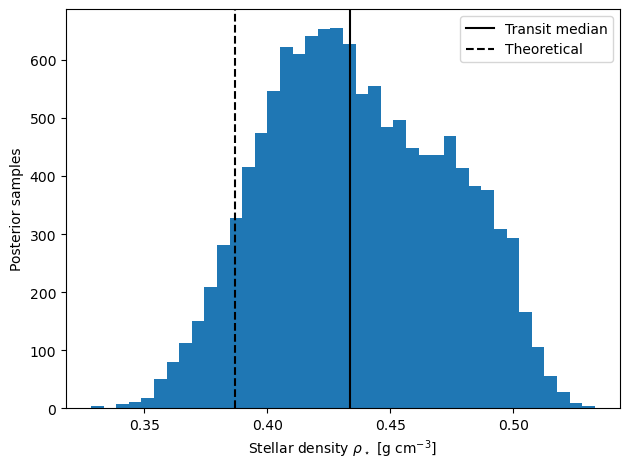

In [22]:
fig, ax = subplots()
ax.hist(rho_transit, bins=40)
ax.axvline(rho50, c='k', label='Transit median')
ax.axvline(rho_theory.value, c='k', ls='--', label='Theoretical')
setp(ax, xlabel=r'Stellar density $\rho_\star$ [g cm$^{-3}$]',
     ylabel='Posterior samples')
ax.legend()
fig.tight_layout()

From the plot we can see that the theoretical value lies close to the transit median distribution value.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

Often in models such as those that have been plotted above, we can see that parameters are not independently constrained, and unceirtanties are linked to each other, meaning wider unceirtanties. What this means in practice then, is that additional data (such as RV and transit data both taken into account, as discussed previously) is needed to give further confidence in the data and to lower unceirtanties.

---
<center>&copy;2026 Hannu Parviainen</center>